In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [4]:
# pip install joblib

In [5]:
dataset = pd.read_csv('Dataset/StratifiedNatalityDataset.csv')

In [6]:
dataset.shape

(63685, 83)

# Defining Preterm Target

In [7]:
dataset['preterm'].value_counts()

0    40014
1    23671
Name: preterm, dtype: int64

In [8]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'obgest_flg', 'compgst_imp']
dataset = dataset.drop(columns=target_leakage_cols)

In [9]:
dataset.shape

(63685, 75)

# Drop columns with >80% missing values

In [10]:
missing_90_cols = [col for col in dataset.columns if dataset[col].isnull().mean()>0.9]

In [11]:
dataset = dataset.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", dataset.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'lmpused']
New shape: (63685, 69)


# Visualizing the preterm and not-preterm data

In [12]:
dataset['preterm'].value_counts()

0    40014
1    23671
Name: preterm, dtype: int64

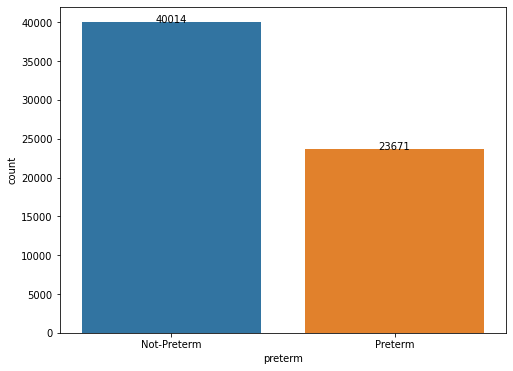

In [13]:
import seaborn as sns
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dataset, x='preterm')
plt.xticks([0, 1], ['Not-Preterm', 'Preterm'])
for p in ax.patches:
    # print(p)
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.savefig('BeforeSplitting.png', dpi=300)
plt.show()

In [14]:
dataset.shape

(63685, 69)

In [15]:
unknown_code_map = {
    'mbstate_rec' : 3,'meduc' : 9,'fagecomb' : 99, 'fagerec11': 11, 'frace31': 99,'frace6': 9,'frace15': 99,'feduc': 9,'priorlive': 99,'priordead': 99,
    'priorterm': 99,'lbo_rec' : 9,'tbo_rec': 9,'illb_r': 999,'illb_r11': 99,'ilop_r': 999,
    'ilop_r11': 99,'ilp_r': 999,'ilp_r11': 99,'precare5': 5,'previs_rec': 12, 'cig_0': 99,'cig_1': 99,'cig_2': 99,'cig_3': 99,
    'cig0_r': 6,'cig1_r': 6,'cig2_r': 6,'cig3_r': 6,'m_ht_in': 99,
    'bmi': 99.9,'bmi_r': 9,'pwgt_r': 999,'dwgt_r':999,'wtgain': 99,'wtgain_rec': 9,'rf_cesarn': 99,'no_risks': 9,'no_infec': 9,
    'setorder_r': 9,'dlmp_mm': 99,'dlmp_yy': 9999      
    
}

In [16]:
dataset.isnull().sum()[dataset.isnull().sum()>0]

Series([], dtype: int64)

# Train Test split

In [17]:
X = dataset.drop(columns=['preterm'])  # your features
y = dataset['preterm']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('')

In [18]:
y_train.value_counts()

0    32011
1    18937
Name: preterm, dtype: int64

In [19]:
y_test.value_counts()

0    8003
1    4734
Name: preterm, dtype: int64

# Visualizing the Preterm vs Not_Preterm in Train and Test

# Using Seaborn

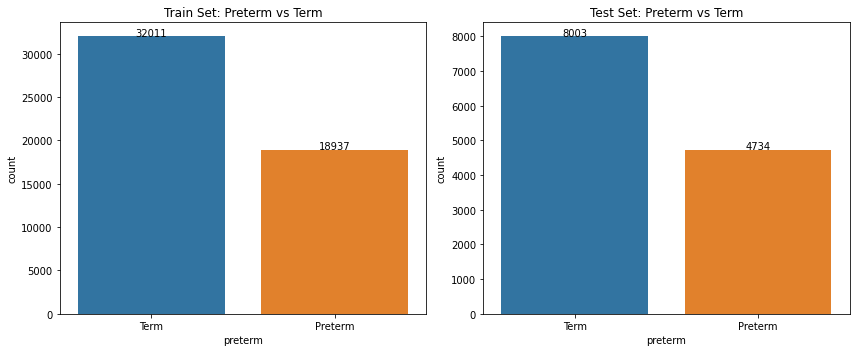

In [20]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Term','Preterm'])
axes[0].set_title('Train Set: Preterm vs Term')
for p in axes[0].patches:
    # print(p)
    height = p.get_height()
    axes[0].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')

    

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Term','Preterm'])
axes[1].set_title('Test Set: Preterm vs Term')
for p in axes[1].patches:
    # print(p)
    height = p.get_height()
    axes[1].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.tight_layout()
plt.show()


In [21]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
corr = X_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs


[('mager14', 'mager', 0.9422980471777356),
 ('mager9', 'mager', 0.9732409939882865),
 ('mager9', 'mager14', 0.9621479513442046),
 ('mrace6', 'mrace31', 0.9315751173826823),
 ('mrace15', 'mrace31', 0.9039572098889204),
 ('mrace15', 'mrace6', 0.9652356137352402),
 ('fagerec11', 'fagecomb', 0.9445862572561596),
 ('frace6', 'frace31', 0.9245904540442536),
 ('frace15', 'frace31', 0.9981974574588929),
 ('frace15', 'frace6', 0.9429673684511293),
 ('illb_r11', 'illb_r', 0.9987181376258216),
 ('ilop_r11', 'ilop_r', 0.9992822895948168),
 ('ilp_r11', 'ilp_r', 0.9989605267547548),
 ('cig_1', 'cig_0', 0.9943076494329508),
 ('cig_2', 'cig_0', 0.9945344322634057),
 ('cig_2', 'cig_1', 0.9986525492076931),
 ('cig0_r', 'cig_0', 0.9927844287915603),
 ('cig0_r', 'cig_1', 0.9843573214074918),
 ('cig0_r', 'cig_2', 0.9839388249105102),
 ('cig1_r', 'cig_0', 0.9909102231108858),
 ('cig1_r', 'cig_1', 0.9958573562697713),
 ('cig1_r', 'cig_2', 0.9937208198609209),
 ('cig1_r', 'cig0_r', 0.9890466604935751),
 ('cig

In [22]:
# # Convert to a matrix
# df_pairs = pd.DataFrame(corr_pairs, columns=['Feature1', 'Feature2', 'Correlation'])

# # Pivot into matrix form
# corr_matrix = df_pairs.pivot(index='Feature1', columns='Feature2', values='Correlation')

# # Plot heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# plt.title("Heatmap of Highly Correlated Feature Pairs")

# plt.show()

In [23]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']


In [24]:
X_train = X_train.drop(columns=cols_to_drop)
print(X_train.shape)


(50948, 50)


In [25]:
X_test = X_test.drop(columns = cols_to_drop)
print(X_test.shape)

(12737, 50)


In [26]:
X_train = X_train.drop(columns=['previs', 'precare', 'no_risks', 'no_infec', 'cig_rec'])

In [27]:
X_test = X_test.drop(columns=['previs', 'precare', 'no_risks', 'no_infec', 'cig_rec'])

In [28]:
X_train = X_train.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])
X_test = X_test.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])

In [29]:
print(X_train.shape)
print(X_test.shape)

(50948, 41)
(12737, 41)


# Data Preprocessing

# Step 1: Continuous / Numeric Features Preprocessing   (12)

In [30]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)


12

In [31]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [32]:
unknown_code_map.items()

dict_items([('fagecomb', 99), ('priorlive', 99), ('priordead', 99), ('priorterm', 99), ('illb_r', 999), ('ilop_r', 999), ('ilp_r', 999), ('m_ht_in', 99), ('bmi', 99.9), ('wtgain', 99), ('rf_cesarn', 99)])

In [33]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in dataset.columns:
        X_train[col] = X_train[col].replace(code, pd.NA)

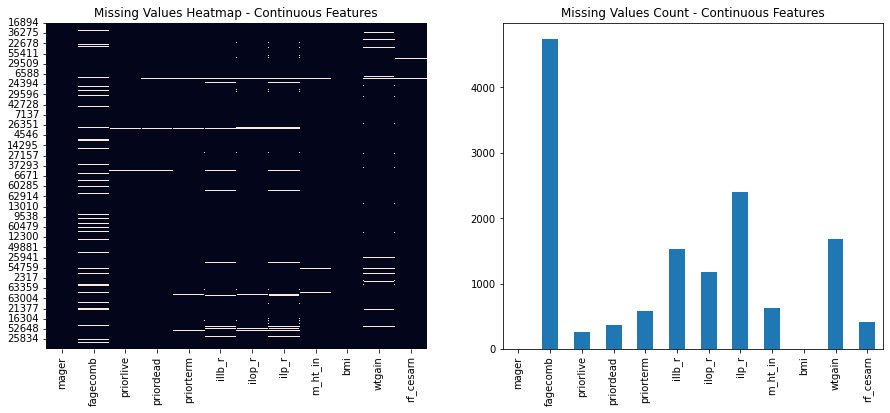

In [34]:

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(X_train[numeric_continuous_features].isna(), cbar=False)
plt.title("Missing Values Heatmap - Continuous Features")
# plt.show()

plt.subplot(1, 2, 2)
X_train[numeric_continuous_features].isna().sum().plot(kind='bar')
plt.title("Missing Values Count - Continuous Features")
plt.show()


In [35]:
(X_train[numeric_continuous_features].isnull().sum()/X_train.shape[0])*100

mager        0.000000
fagecomb     9.319306
priorlive    0.524064
priordead    0.726231
priorterm    1.132527
illb_r       3.003062
ilop_r       2.321975
ilp_r        4.708723
m_ht_in      1.234592
bmi          0.000000
wtgain       3.293554
rf_cesarn    0.804742
dtype: float64

# Step 2: Ordinal Features Preprocessing (11)

In [36]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec']
len(ordinal_features)

10

# Step 3: One-Hot Features (19)

In [37]:

all_features = X_train.columns.tolist()
one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
print(one_hot_features)
len(one_hot_features)

['rf_cesar', 'mrace6', 'rf_pdiab', 'ip_hepc', 'rf_ehype', 'ip_syph', 'rf_ppterm', 'rf_inftr', 'mar_p', 'ip_hepb', 'rf_phype', 'rf_gdiab', 'frace6', 'rf_fedrg', 'ip_gon', 'rf_artec', 'rf_ghype', 'dmar', 'ip_chlam']


19

# Build Preprocessing Pipeline

In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [39]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = 'passthrough'

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

In [40]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_continuous_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('onehot', categorical_pipeline, one_hot_features)
    ]
)

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [42]:
X_train_processed

array([[-1.24603075, -0.17869016, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.74836483, -0.17869016, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.24696372,  3.55117343,  1.81670621, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.41503259, -0.45497635,  0.09164032, ...,  1.        ,
         0.        ,  0.        ],
       [-0.91363149,  0.37388222, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       [-1.07983112, -0.17869016, -0.77089263, ...,  1.        ,
         0.        ,  0.        ]])

In [43]:
X_test_processed

array([[-1.57843001, -1.14569183, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.41596556,  1.61717009,  0.95417326, ...,  1.        ,
         0.        ,  0.        ],
       [-1.74462964, -1.56012112, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.24883296, -0.73126255, -0.77089263, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.91176225,  2.30788557,  1.81670621, ...,  1.        ,
         0.        ,  0.        ],
       [-1.41223038, -0.31683326, -0.77089263, ...,  1.        ,
         0.        ,  0.        ]])

# Train a Baseline Classifier (Random Forest)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
# clf = RandomForestClassifier(random_state=42)
# clf.fit(X_train_processed, y_train)

In [46]:
# y_pred = clf.predict(X_test_processed)

In [47]:
# # Evaluate model
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy:.2f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

In [48]:
# cm = confusion_matrix(y_test, y_pred)
# print(cm)

NameError: name 'y_pred' is not defined

# Hyperparameter Tuning (Randomized Search / Grid Search)

In [49]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [50]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_dist,
    n_iter = 15,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_random.fit(X_train_processed, y_train)

print("Best parameters:", rf_random.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


In [51]:
best_model = rf_random.best_estimator_
# y_pred_best = best_model.predict(X_test_processed)

# print(confusion_matrix(y_test, y_pred_best))
# print(classification_report(y_test, y_pred_best))


In [52]:
joblib.dump(best_model, "preterm_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [54]:
import pickle

with open("preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)
    
preprocessor

array(['mager', 'mrace6', 'mar_p', 'dmar', 'meduc', 'fagecomb', 'frace6',
       'feduc', 'priorlive', 'priordead', 'priorterm', 'tbo_rec',
       'illb_r', 'ilop_r', 'ilp_r', 'precare5', 'previs_rec', 'cig0_r',
       'cig1_r', 'cig2_r', 'cig3_r', 'm_ht_in', 'bmi', 'wtgain',
       'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype', 'rf_ehype',
       'rf_ppterm', 'rf_inftr', 'rf_fedrg', 'rf_artec', 'rf_cesar',
       'rf_cesarn', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb', 'ip_hepc',
       'dplural'], dtype=object)

In [56]:
import joblib

preprocessor = joblib.load("preprocessor.pkl")
type(preprocessor)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['mager', 'fagecomb', 'priorlive', 'priordead',
                                  'priorterm', 'illb_r', 'ilop_r', 'ilp_r',
                                  'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']),
                                ('ord', 'passthrough',
                                 ['meduc', 'feduc', 'cig0_r', 'cig1_r',
                                  'cig2_r', 'cig3_r', 'precare5', 'previs_rec',
                                  'dplural', 'tbo_rec']),
                                ('onehot',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                          

# Using Class weight

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=[0,1], y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)

# rf_random = RandomizedSearchCV(
#     estimator = rf,
#     param_distributions = param_dist,
#     n_iter = 15,
#     scoring = 'roc_auc',
#     cv = 3,
#     verbose = 2,
#     random_state = 42,
#     n_jobs = -1
# )

# rf_random.fit(X_train_processed, y_train)

# print("Best parameters:", rf_random.best_params_)


In [ ]:
# best_model = rf_random.best_estimator_
# y_pred_best = best_model.predict(X_test_processed)

# print(confusion_matrix(y_test, y_pred_best))
# print(classification_report(y_test, y_pred_best))

# Randomized + GridSearch CV

# Using SVM

In [ ]:
# from sklearn.svm import SVC

# svm_model = Pipeline(steps=[
#     ('preprocess', preprocessor),
#     ('svm', SVC(
#         kernel='linear',
#         class_weight='balanced',
#         random_state=42
#     ))
# ])

# svm_model.fit(X_train, y_train)
# y_pred = svm_model.predict(X_test)


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))


In [ ]:
# from sklearn.svm import SVC

# svm_model = Pipeline(steps=[
#     ('preprocess', preprocessor),
#     ('svm', SVC(
#         kernel='rbf',
#         C = 1.0,
#         gamma='scale',
#         class_weight='balanced',
#         random_state=42
#     ))
# ])

# svm_model.fit(X_train, y_train)
# y_pred = svm_model.predict(X_test)


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))